<a href="https://colab.research.google.com/github/miller00315/AI-For-Beginners/blob/main/decicion_tree_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/vqrca/ml-datasets/refs/heads/main/Heart_Disease_Prediction.csv')

In [3]:
pd.set_option('display.max_columns', None)
print(df.head())

   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       Absence  
2                        0   

In [4]:
df.shape

(270, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
df_encoded = pd.get_dummies(df, columns=['Chest pain type', 'Thallium'], dtype=int)

df_encoded.head()

,Age,Sex,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Heart Disease,Chest pain type_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,Thallium_3,Thallium_6,Thallium_7
0,70,1,130,322,0,2,109,0,2.4,2,3,Presence,0,0,0,1,1,0,0
1,67,0,115,564,0,2,160,0,1.6,2,0,Absence,0,0,1,0,0,0,1
2,57,1,124,261,0,0,141,0,0.3,1,0,Presence,0,1,0,0,0,0,1
3,64,1,128,263,0,0,105,1,0.2,2,1,Absence,0,0,0,1,0,0,1
4,74,0,120,269,0,2,121,1,0.2,1,1,Absence,0,1,0,0,1,0,0


In [7]:
X = df_encoded.drop('Heart Disease', axis=1)
y = df_encoded['Heart Disease']

In [8]:
X

,Age,Sex,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Chest pain type_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,Thallium_3,Thallium_6,Thallium_7
0,70,1,130,322,0,2,109,0,2.4,2,3,0,0,0,1,1,0,0
1,67,0,115,564,0,2,160,0,1.6,2,0,0,0,1,0,0,0,1
2,57,1,124,261,0,0,141,0,0.3,1,0,0,1,0,0,0,0,1
3,64,1,128,263,0,0,105,1,0.2,2,1,0,0,0,1,0,0,1
4,74,0,120,269,0,2,121,1,0.2,1,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,172,199,1,0,162,0,0.5,1,0,0,0,1,0,0,0,1
266,44,1,120,263,0,0,173,0,0.0,1,0,0,1,0,0,0,0,1
267,56,0,140,294,0,2,153,0,1.3,2,0,0,1,0,0,1,0,0
268,57,1,140,192,0,0,148,0,0.4,2,0,0,0,0,1,0,1,0


In [9]:
y

,Heart Disease
0,Presence
1,Absence
2,Presence
3,Absence
4,Absence
...,...
265,Absence
266,Absence
267,Absence
268,Absence


In [10]:
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(X,
                                                        y,
                                                        test_size=0.2,
                                                        stratify=y,
                                                        random_state=42)

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
modelo_arvore = DecisionTreeClassifier(random_state=5389)

In [13]:
modelo_arvore.fit(X_treino, y_treino)

DecisionTreeClassifier(random_state=5389)

In [14]:
predicoes = modelo_arvore.predict(X_teste)

In [15]:
predicoes

array(['Absence', 'Absence', 'Absence', 'Presence', 'Absence', 'Absence',
       'Absence', 'Presence', 'Presence', 'Presence', 'Absence',
       'Presence', 'Absence', 'Presence', 'Presence', 'Presence',
       'Absence', 'Presence', 'Absence', 'Presence', 'Absence',
       'Presence', 'Absence', 'Absence', 'Absence', 'Presence',
       'Presence', 'Absence', 'Absence', 'Presence', 'Absence', 'Absence',
       'Presence', 'Absence', 'Absence', 'Presence', 'Presence',
       'Absence', 'Absence', 'Absence', 'Presence', 'Absence', 'Presence',
       'Presence', 'Presence', 'Presence', 'Absence', 'Presence',
       'Presence', 'Absence', 'Presence', 'Presence', 'Absence',
       'Presence'], dtype=object)

In [16]:
probabilidades = modelo_arvore.predict_proba(X_teste)

probabilidades

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

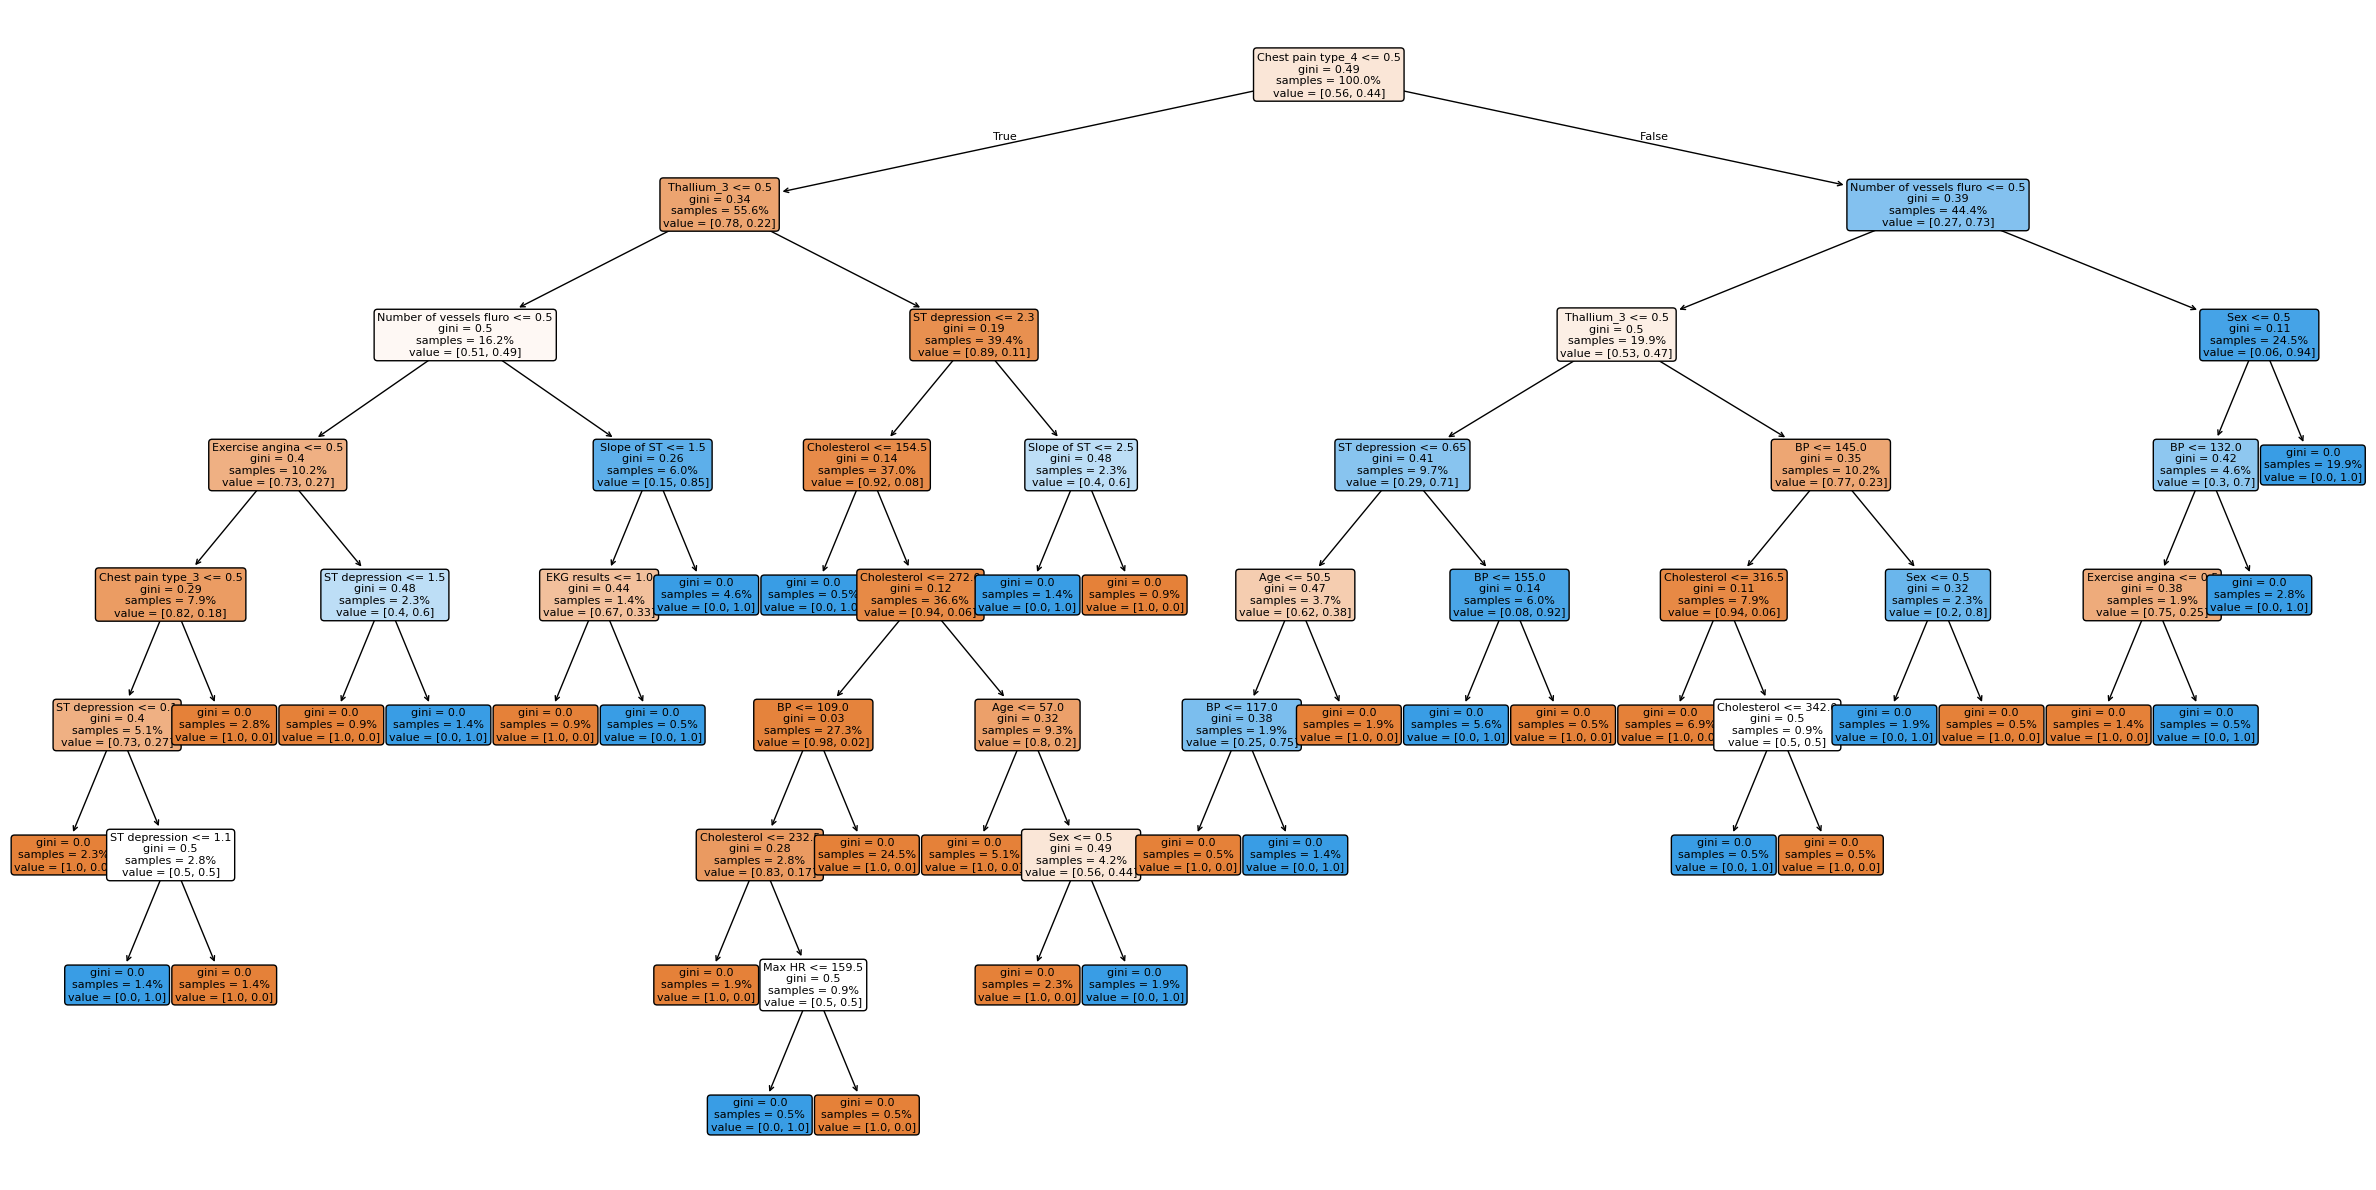

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    modelo_arvore,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    #max_depth=3,
    fontsize=8,
    proportion=True,
    precision=2
)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
acuracia_teste = accuracy_score(y_teste, predicoes)
print(f'Test accuracy: {acuracia_teste:.2%}')

Acurácia nos dados de teste: 79.63%


In [20]:
predicoes_treino = modelo_arvore.predict(X_treino)

acuracia_treino= accuracy_score(y_treino, predicoes_treino)
print(f'Train accuracy: {acuracia_treino:.2%}')

Train accuracy: 100.00%


In [21]:
from sklearn.metrics import classification_report

In [22]:
relatorio = classification_report(y_teste, predicoes)

print(relatorio)

              precision    recall  f1-score   support

     Absence       0.85      0.77      0.81        30
    Presence       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54



In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

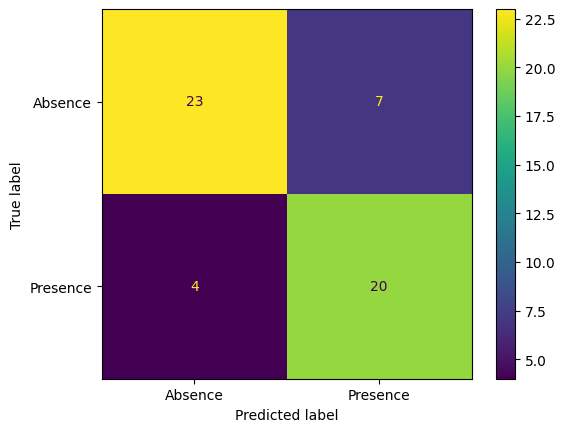

In [24]:
ConfusionMatrixDisplay.from_estimator(modelo_arvore, X_teste, y_teste);

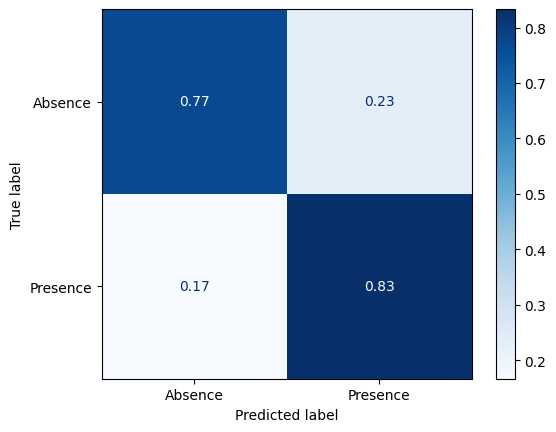

In [25]:
ConfusionMatrixDisplay.from_estimator(modelo_arvore, X_teste, y_teste,
                                      normalize = 'true',
                                      cmap = 'Blues');

In [26]:
from sklearn.metrics import RocCurveDisplay

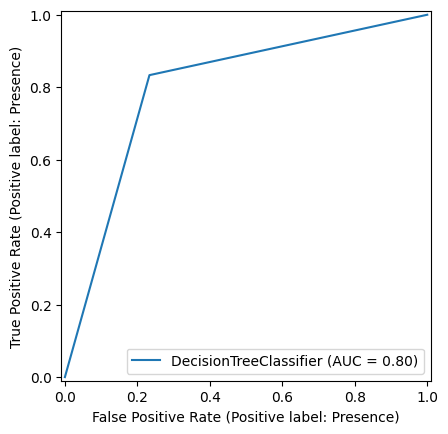

In [27]:
RocCurveDisplay.from_estimator(
    modelo_arvore,
    X_teste,
    y_teste
);

In [28]:
modelo_arvore_podada = DecisionTreeClassifier(random_state=5389, max_depth=3)

In [29]:
modelo_arvore_podada.fit(X_treino, y_treino)

DecisionTreeClassifier(max_depth=3, random_state=5389)

In [30]:
predicoes_podada = modelo_arvore_podada.predict(X_teste)

In [31]:
predicoes_podada_treino = modelo_arvore_podada.predict(X_treino)

In [32]:
acuracia_treino_podada = accuracy_score(y_treino, predicoes_podada_treino)
print(f'Acurácia nos dados de treino (max_depth=3): {acuracia_treino_podada:.2f}')

Acurácia nos dados de treino (max_depth=3): 0.86


In [33]:
acuracia_teste_podada = accuracy_score(y_teste, predicoes_podada)
print(f'Acurácia nos dados de teste (max_depth=3): {acuracia_teste_podada:.2f}')

Acurácia nos dados de teste (max_depth=3): 0.83


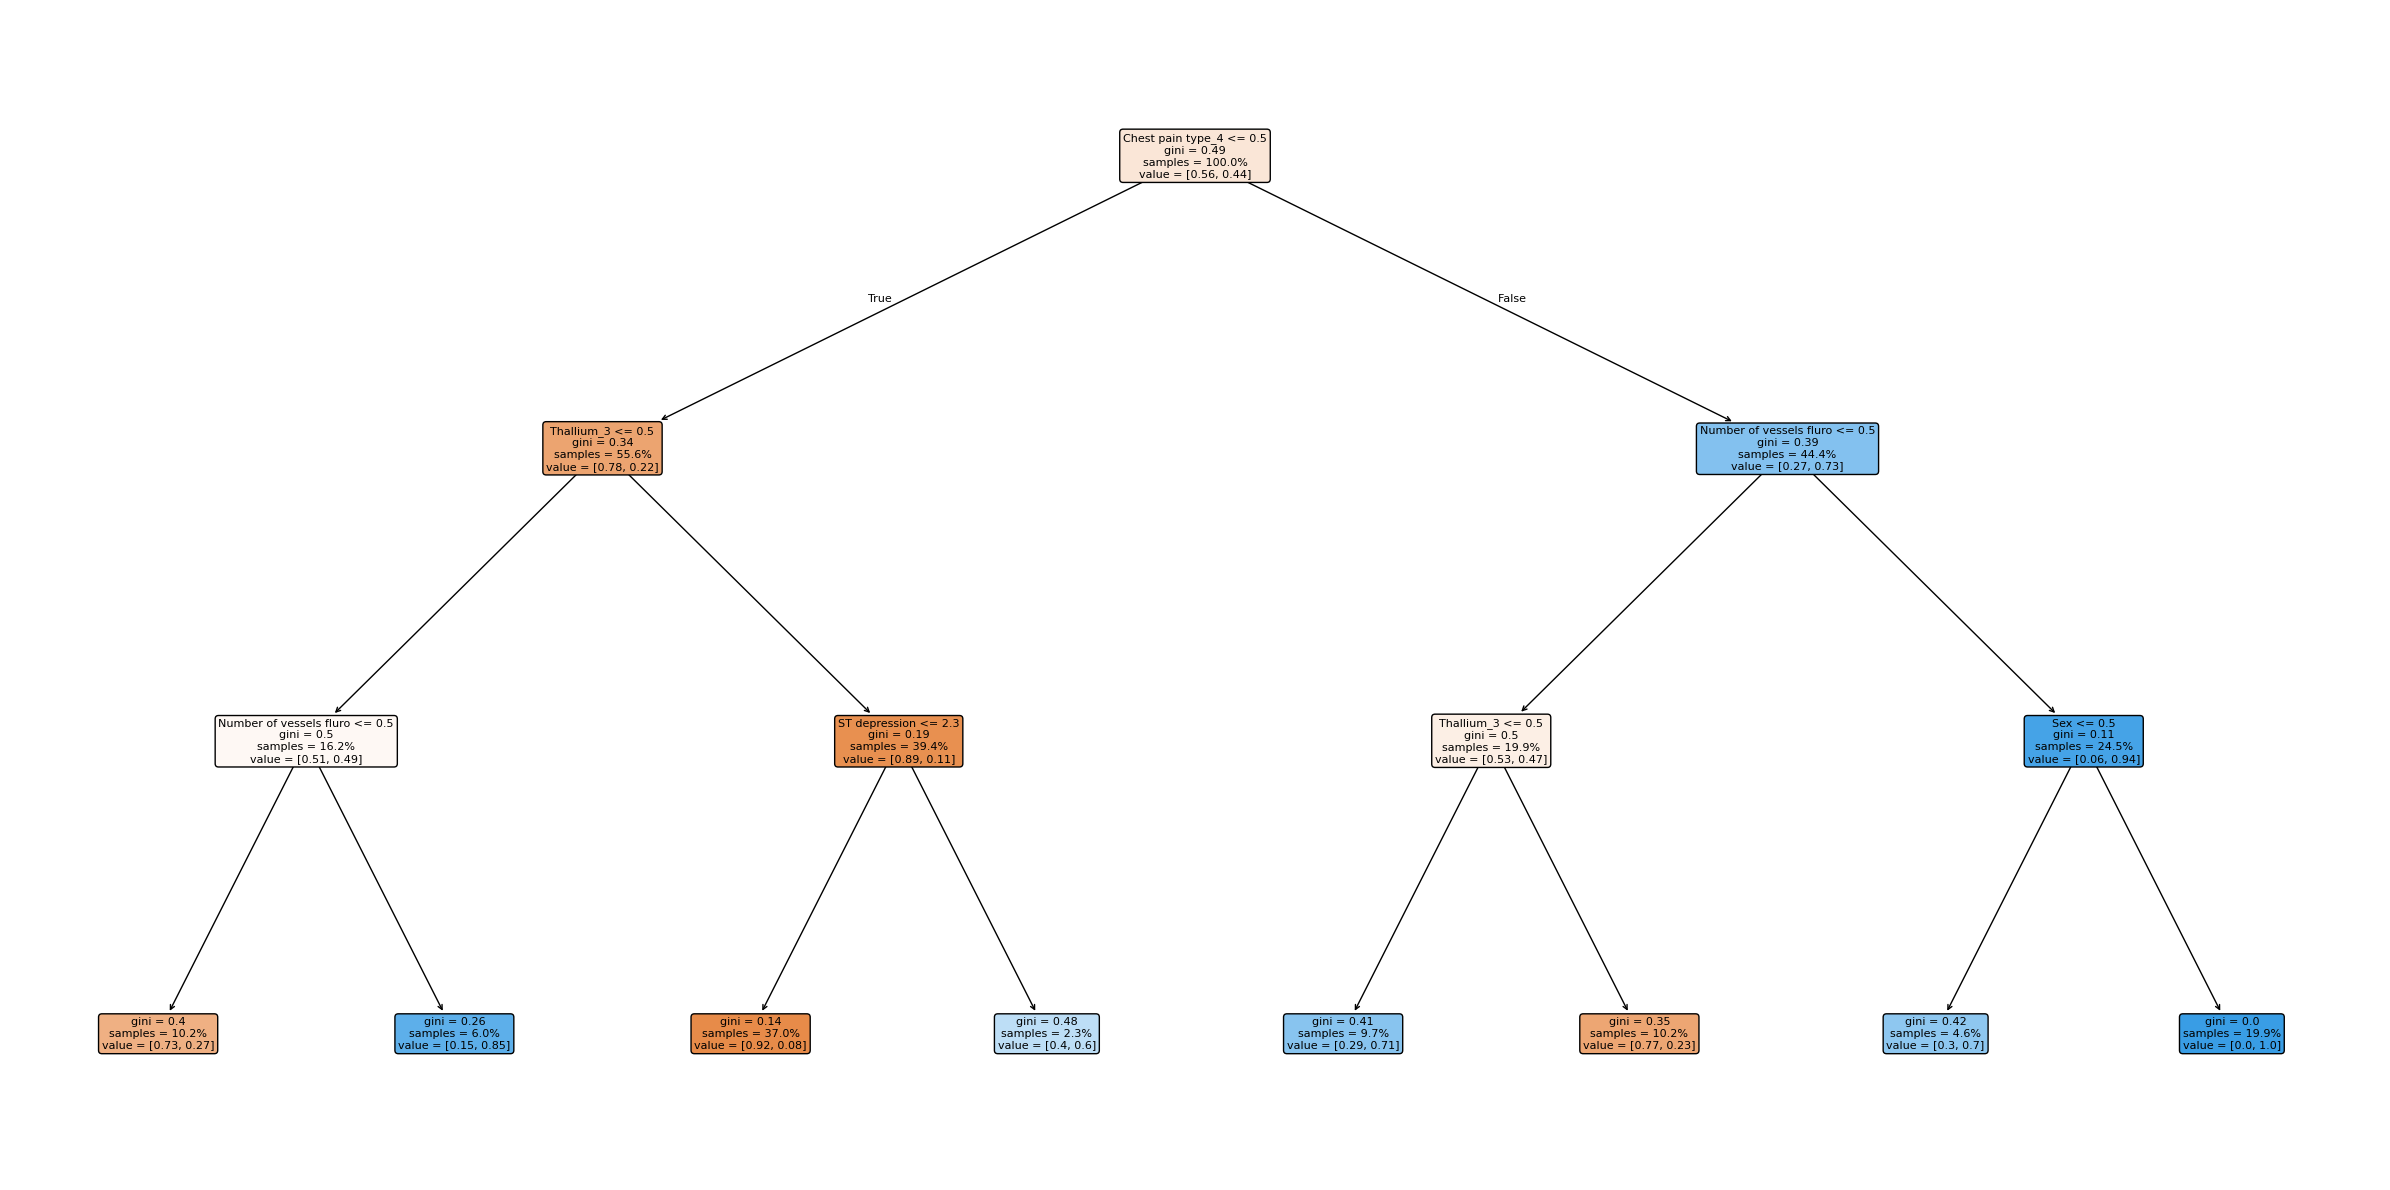

In [34]:
plt.figure(figsize=(24, 12))

plot_tree(
    modelo_arvore_podada,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    proportion=True,
    precision=2
)

plt.tight_layout()
plt.show()

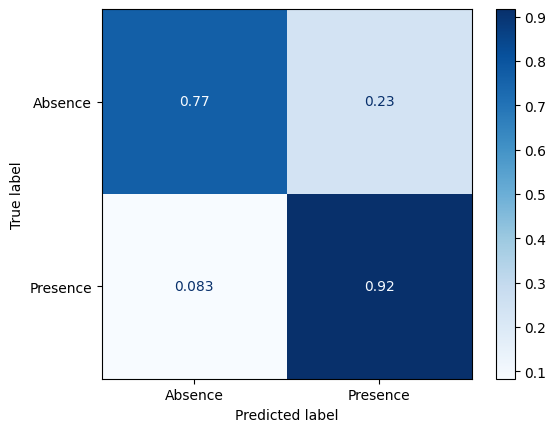

In [35]:
ConfusionMatrixDisplay.from_estimator(modelo_arvore_podada, X_teste, y_teste,
                                      normalize = 'true',
                                      cmap = 'Blues');

In [37]:
from sklearn.model_selection import cross_val_score

In [38]:
modelo = DecisionTreeClassifier(random_state=5389, max_depth=3)
scores = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')
scores


array([0.72222222, 0.75925926, 0.83333333, 0.85185185, 0.85185185])

In [40]:
print("O resultado da validação cruzada é %0.2f%% acurácia com desvio padrão de %0.2f%%"
      % (scores.mean() * 100, scores.std() * 100))


O resultado da validação cruzada é 80.37% acurácia com desvio padrão de 5.32%


In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [42]:
validacao = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=5389
)

scores = cross_val_score(
    modelo_arvore_podada,
    X,
    y,
    cv=validacao,
    scoring='accuracy'
)

scores

array([0.88888889, 0.74074074, 0.81481481, 0.83333333, 0.81481481])

In [43]:
print("O resultado da validação cruzada é %0.2f%% acurácia com desvio padrão de %0.2f%%"
      % (scores.mean() * 100, scores.std() * 100))

O resultado da validação cruzada é 81.85% acurácia com desvio padrão de 4.74%


In [44]:
from sklearn.model_selection import cross_validate

In [45]:
resultado = cross_validate(
    modelo_arvore_podada,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
)

resultado


{'fit_time': array([0.00644064, 0.00631332, 0.00586939, 0.0056355 , 0.00553823]),
 'score_time': array([0.01618552, 0.01622844, 0.01507282, 0.01495647, 0.01521897]),
 'test_accuracy': array([0.72222222, 0.75925926, 0.83333333, 0.85185185, 0.85185185]),
 'test_precision_macro': array([0.72556391, 0.77662957, 0.83766234, 0.86176471, 0.85369318]),
 'test_recall_macro': array([0.70833333, 0.74166667, 0.825     , 0.84166667, 0.84583333]),
 'test_f1_macro': array([0.71019678, 0.74444849, 0.82857143, 0.84659091, 0.84852735])}

In [46]:
resultados_metricas = pd.DataFrame({
    'Média': [
        resultado['test_accuracy'].mean(),
        resultado['test_precision_macro'].mean(),
        resultado['test_recall_macro'].mean(),
        resultado['test_f1_macro'].mean()
    ],
    'Desvio Padrão': [
        resultado['test_accuracy'].std(),
        resultado['test_precision_macro'].std(),
        resultado['test_recall_macro'].std(),
        resultado['test_f1_macro'].std()
    ]
},
index=['Acurácia', 'Precisão', 'Recall', 'F1-Score'])

In [47]:
resultados_metricas['Média'] = resultados_metricas['Média'].apply(lambda x: f'{x:.2%}')
resultados_metricas['Desvio Padrão'] = resultados_metricas['Desvio Padrão'].apply(lambda x: f'{x:.2%}')

resultados_metricas

,Média,Desvio Padrão
Acurácia,80.37%,5.32%
Precisão,81.11%,5.21%
Recall,79.25%,5.65%
F1-Score,79.57%,5.73%


In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
grade_parametros = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

In [51]:
modelo_arvore_grid = DecisionTreeClassifier(random_state=5389)

In [52]:
grid_search = GridSearchCV(
    estimator=modelo_arvore_grid,
    param_grid=grade_parametros,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [53]:
grid_search.fit(X, y)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=5389),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 5, 10, 20]},
             scoring='accuracy', verbose=1)

In [54]:
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor acurácia média na validação cruzada: {grid_search.best_score_:.2f}")

Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10}
Melhor acurácia média na validação cruzada: 0.82


In [55]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=10,
                       random_state=5389)

In [56]:
colunas_resultado = [
    'param_max_depth',
    'param_min_samples_leaf',
    'param_criterion',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

In [57]:
resultados = (
    pd.DataFrame(grid_search.cv_results_)[colunas_resultado]
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

resultados

,param_max_depth,param_min_samples_leaf,param_criterion,mean_test_score,std_test_score,rank_test_score
0,3,10,entropy,0.822222,0.043192,1
1,3,5,entropy,0.818519,0.041243,2
2,7,10,entropy,0.814815,0.040572,3
3,5,10,entropy,0.814815,0.040572,3
4,10,10,entropy,0.814815,0.040572,3
5,3,5,gini,0.811111,0.044444,6
6,3,1,entropy,0.811111,0.048855,6
7,3,10,gini,0.811111,0.050239,6
8,10,10,gini,0.807407,0.043192,9
9,7,10,gini,0.807407,0.043192,9


In [58]:
modelo_arvore_otimizada = DecisionTreeClassifier(random_state=5389, criterion='entropy', max_depth=3, min_samples_leaf=10)

In [59]:
modelo_arvore_otimizada.fit(X_treino, y_treino)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=10,
                       random_state=5389)

In [60]:
predicoes_otimizada = modelo_arvore_otimizada.predict(X_teste)

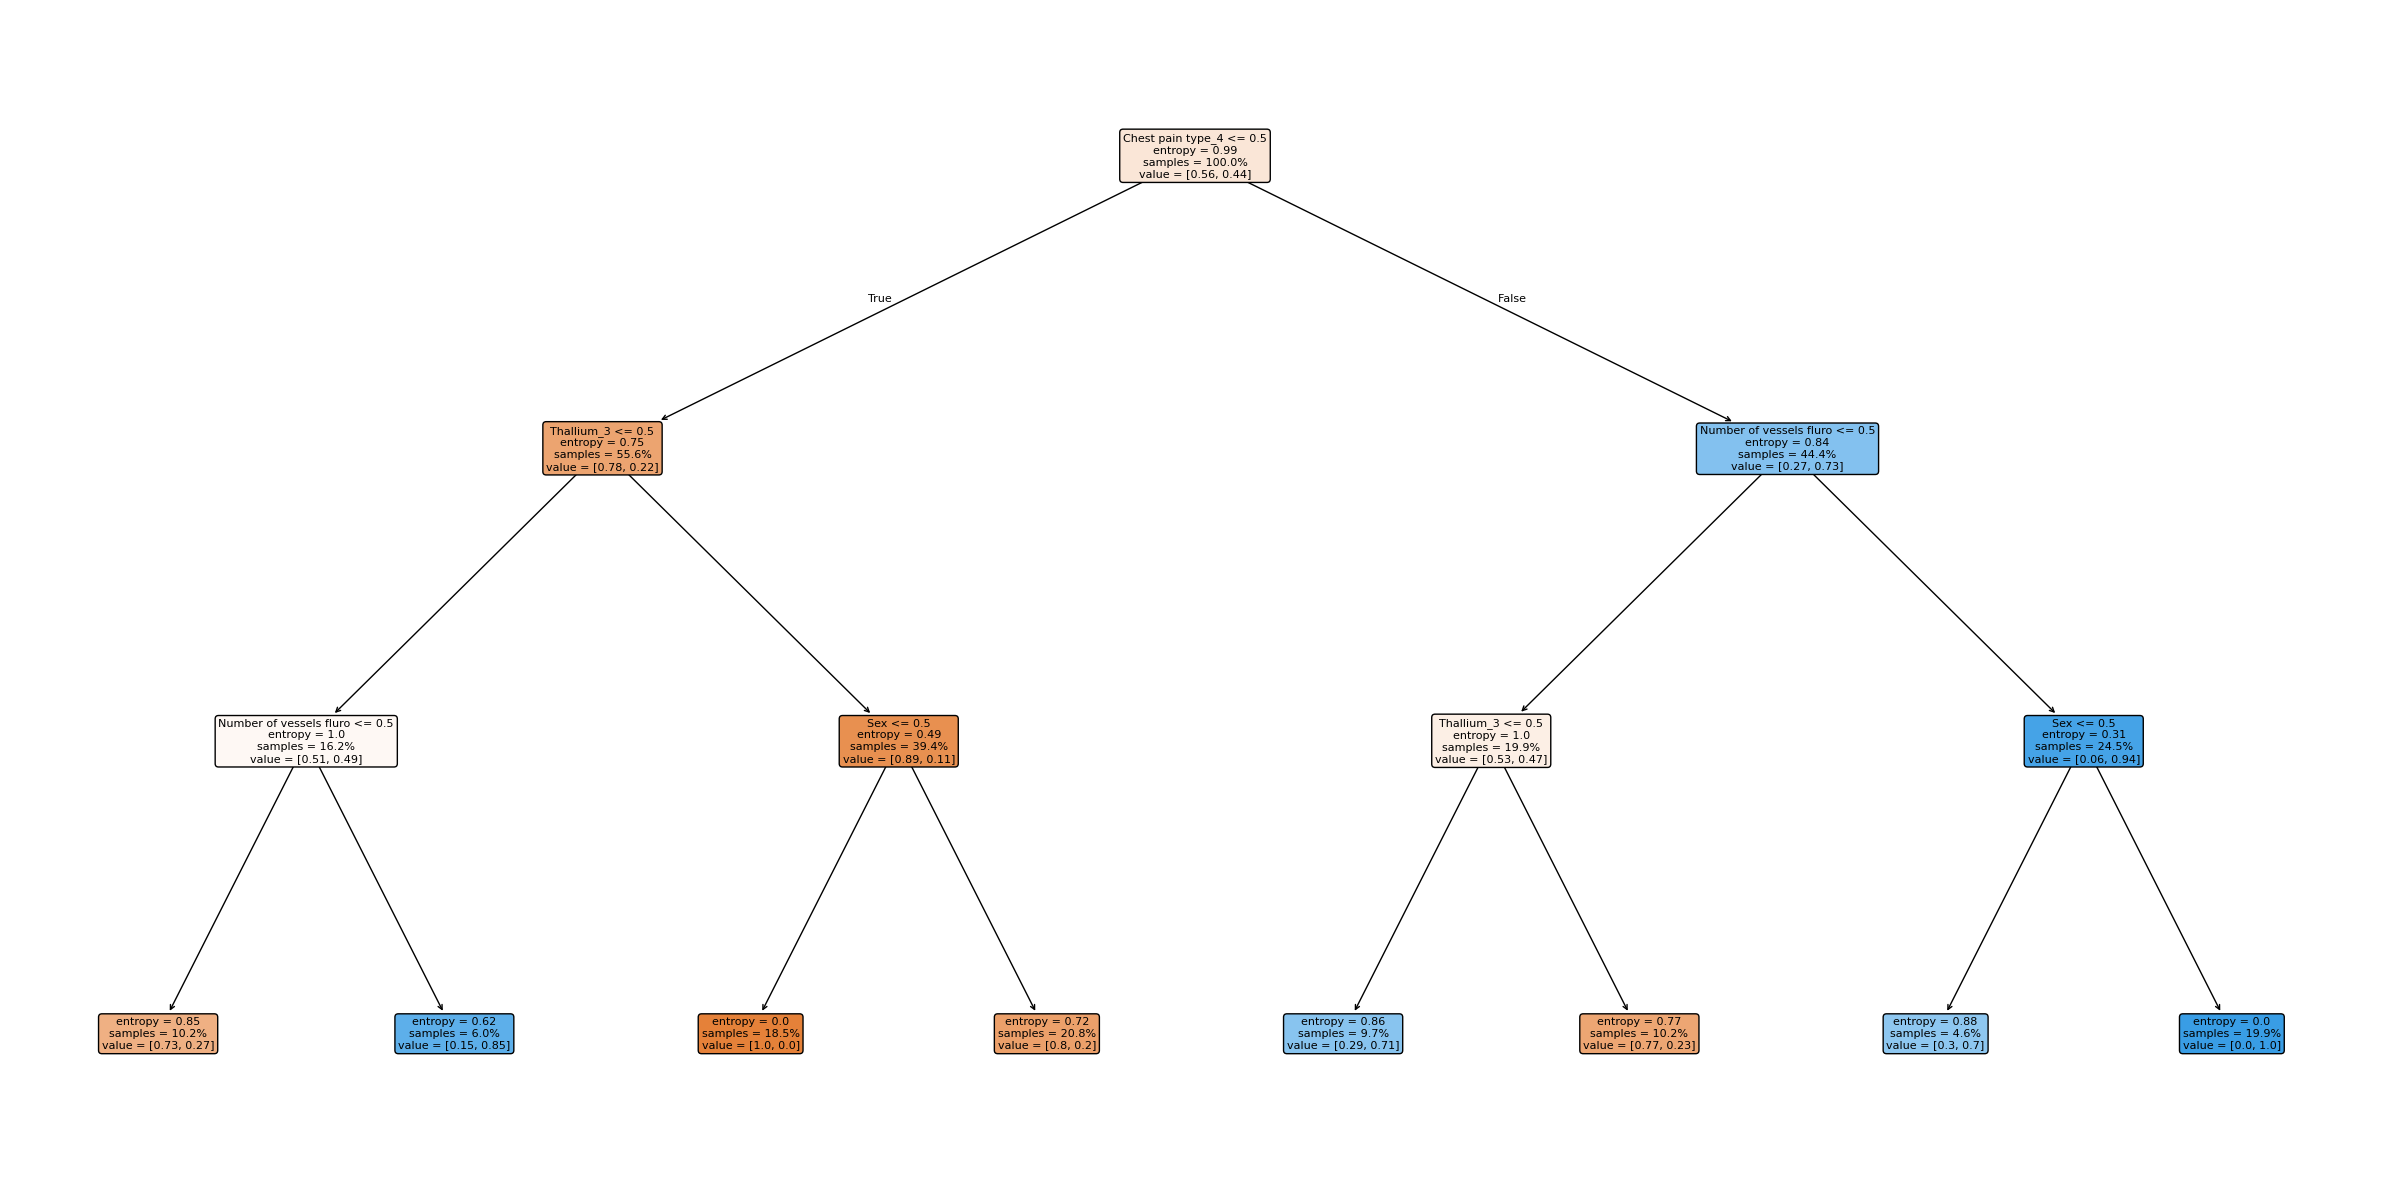

In [61]:
plt.figure(figsize=(24, 12))

plot_tree(
    modelo_arvore_otimizada,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    proportion=True,
    precision=2
)

plt.tight_layout()
plt.show()


In [62]:
predicoes_treino_otimizada = modelo_arvore_otimizada.predict(X_treino)

In [63]:
acuracia_treino_otimizada = accuracy_score(y_treino, predicoes_treino_otimizada )
print(f'Acurácia nos dados de treino (árvore ajustada): {acuracia_treino_otimizada:.2%}')

Acurácia nos dados de treino (árvore ajustada): 85.65%


In [64]:
acuracia_teste_otimizada  = accuracy_score(y_teste, predicoes_otimizada)
print(f'Acurácia nos dados de teste (árvore ajustada): {acuracia_teste_otimizada:.2%}')

Acurácia nos dados de teste (árvore ajustada): 85.19%


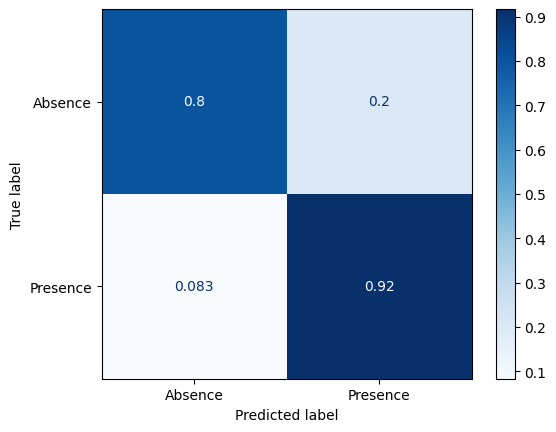

In [65]:
ConfusionMatrixDisplay.from_estimator(modelo_arvore_otimizada,
                                      X_teste, y_teste,
                                      normalize = 'true',
                                      cmap = 'Blues');

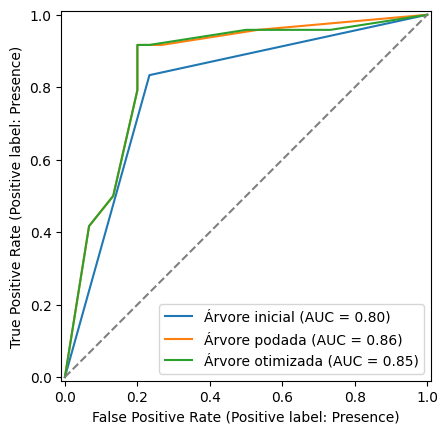

In [66]:
ax = RocCurveDisplay.from_estimator(
    modelo_arvore,
    X_teste,
    y_teste,
    name='Árvore inicial',
    pos_label='Presence'
).ax_

RocCurveDisplay.from_estimator(
    modelo_arvore_podada,
    X_teste,
    y_teste,
    name='Árvore podada',
    pos_label='Presence',
    ax=ax
)

RocCurveDisplay.from_estimator(
    modelo_arvore_otimizada,
    X_teste,
    y_teste,
    name='Árvore otimizada',
    pos_label='Presence',
    ax=ax
)

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.legend()
plt.show()